

This is part of my a learning process and individual exploration on the bridge between electrochemistry and data science. 

## About the Data set

The data set can be found in the following (link)[https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip] and more information can be accessed in a relevant citation: 
    - B. Saha and K. Goebel (2007). “Battery Data Set”, NASA Prognostics Data Repository, NASA Ames Research Center, Moffett Field, CA

SOH: State of health estimation is a concept associated tothe life prediction of Li-ion batteries. It is a relative variable as it compares the current state of the battery with its initial condition: 
$$
SOH = \frac{\text{Current actual capacity (Ah)}}{\text{Nominal Capacity (Ah)}} x 100
$$

The EoL (end of life) of the battery is defined as when the capacity is lower than the acceptable performance threshold (APT), which is ~70% of the rated capacity. 

Battery aging can be defined based on: 
(i) calendar aging : Associated to the consequences of battery storage. 
(ii) cycle aging: Associated with impact of the battery utilization periods. 

Main problem: There is not a single parameter that can determine the exact SOH of a battery, but rather a complex network of related aspects. 

Main question: Can the SOH of a battery be predicted? 

### Relevant libraries for this notebook

In [10]:
#importing libraries
import pandas as pd 
import numpy as np 
import os 
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
import importlib
import utils


In [11]:
importlib.reload(utils)
from utils import time_format,preprocessing_meta,battery_cycles_df,continuous_time,current_capacity,visualization_2by2, timeTmax, time_Tmax3,area_under_curve

# Step 1: Understanding the data

## Experiment information

Batteries 5,6,7 and 18: 
- Temperature: 24 C
- **Charging**: **constant current (CC)** mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA.
- **Discharge** : **constant current (CC)** level of 2A until the battery voltage fell to 2.7V, 2.5V, 2.2V and 2.5V for batteries 5 6 7 and 18.
- Impedance: 0.1Hz to 5kHz. 
- **end-of-life (EOL) criteria**, which was a 30% fade in rated capacity <h style="color: #ff4769;"> (from 2Ahr to 1.4Ahr) </h>. <h style="color: #ff4769;">
- note: This dataset can be used for the prediction of both remaining charge (for a given discharge cycle) and remaining useful life (RUL).</h>


Batteries(# 25, 26, 27 and 28) 
- Temperature: (24 deg C).
- Charging:(CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- **Discharge was carried out using a 0.05Hz square wave** loading profile of 4A amplitude and 50% duty cycle until the battery voltage fell to 2.0V, 2.2V, 2.5V and 2.7V for batteries 25, 26, 27 and 28 respectively. 
- Impedance measurement: 0.1Hz to 5kHz. 


Batteries:  (# 29, 30, 31 and 32) 
- Temperature:  **elevated ambient temperature (43 deg C)**. 
- Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- Discharge was carried out at 4A until the battery voltage fell to 2.0V, 2.2V, 2.5V and 2.7V for batteries 29, 30, 31 and 32 respectively. 
- Impedance measurement: 0.1Hz to 5kHz. 


Batteries: (# 33, 34 and 36) 
- Temperature: **room temperature (24 deg C)**. 
- Charging: constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- Discharge was carried out at 4A until the battery voltage fell to 2.0V and 2.2V for batteries 33 and 34 respectively. For battery 36 discharge was done at 2A until voltage fell to 2.7V. 
- Impedance measurement:  0.1Hz to 5kHz. 
- note: <h style="color: #ff4769;">The experiments were carried out until the capacity had reduced to 1.6Ahr (20% fade).</h>


Batteries: (# 38, 39 and 40) 
- temperatures (24 & 44 deg C). 
- Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- Multiple load current levels (1, 2, and 4 A) were used and the discharge runs were stopped at 2.2V, 2.5V and 2.7V for batteries 38, 39 and 40 respectively. 
- Impedance measurement: 0.1Hz to 5kHz.
- note: <h style="color: #ff4769;">The experiments were carried out until the capacity had reduced to 1.6Ahr (20% fade). </h>


Batteries: (# 41 - 44) 
- Temperature: 4 C
- Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- Multiple fixed load current levels (4A and 1A) were used and the discharge runs were stopped at 2V, 2.2V, 2.5V and 2.7V for batteries 41, 42, 43 and 44 respectively. 
- Impedance measurement: 0.1Hz to 5kHz. 
- The experiments were carried out until the capacity had reduced to 1.4Ahr (30% fade). <h style="color: #ff7b47;">
- Note that there are several discharge runs where the capacity was very low. Reasons for this have not been fully analyzed.</h>


Li-ion batteries (# 45 - 48) 
-  temperature of 4 deg C. 
- Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
- Fixed load current level of 1A was used and the discharge runs were stopped at 2V, 2.2V, 2.5V and 2.7V for batteries 45, 46, 47 and 48 respectively. 
- Impedance measurement 0.1Hz to 5kHz. 
- The experiments were carried out until the capacity had reduced to 1.4Ahr (30% fade). <h style="color: #da7e1d;">
- Note that there are several discharge runs where the capacity was very low. Reasons for this have not been fully analyzed.</h>


 Li-ion batteries (# 49 - 52) 
 - temperature of 4 deg C. 
 - Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. 
 - Fixed load current level of 2A was used and the discharge runs were stopped at 2V, 2.2V, 2.5V and 2.7V for batteries 49, 50, 51 and 52 respectively. 
 - Impedance measurement:  0.1Hz to 5kHz. 
 - <h style="color: #ff4769;">The experiments were carried out until the experiment control software crashed.</h>  <h style="color: #da7e1d;">
 - Note that there are several discharge runs where the capacity as well as voltage levels were very low. Reasons for this have not been fully analyzed.</h>


 Li-ion batteries (# 53 - 56) 
 - temperature of 4 deg C. 
 - Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA.
 - Fixed load current level of 2A was used and the discharge runs were stopped at 2V, 2.2V, 2.5V and 2.7V for batteries 53, 54, 55 and 56 respectively. 
 - Impedance measurement  0.1Hz to 5kHz. 
 - The experiments were carried out until the capacity had reduced to 1.4Ahr (30% fade). <h style="color: #da7e1d;">Note that there are several discharge runs where the capacity was very low. Reasons for this have not been fully analyzed.</h>


## Summary of experiments

1. Nominal capacity is 2 Ah 
2. EoL varied between 20 % or 30 % fade. 
3. There are three temperatures tested: 4, 24 and 43 degrees.
4. All charging cycles follow the same protocol. 
5. Discharge cycles vary in loading current: 1-4 A.
6. All impedance protocols are similar. 
4. There are two set of experiments that may be eliminated: 
    - sets 25,26,27,28 because a square wave was used during discharge. This might affect the final result. 
    - sets from 49-52, software crashed  before EoL
5. Warning from 41-onwards because there are measurements with very low capacities.     

## Problem analysis

The data offers charge and discharge cycles, as well as impedance analysis for several batteries under several conditions. 

1. One aspect of SOH: The capacity would change over charge-discharge cycle numbers. More likely, it will decrease.
2. Impedance: would also change over charge-discharge cycles, more likely it will grow.

- These datasets can be used for the prediction of both remaining charge (for a given discharge cycle) and remaining useful life (RUL).



## Metadata

In [12]:
#Metadata

meta = pd.read_csv("metadata.csv")

#Cleaning the format from symbols
meta["start_time"]=meta["start_time"].replace((r'[\[\]]'), '',regex=True)
#Split in columns
meta[["year","month","day","hour","minute","second"]]=meta["start_time"].str.split(n=5,expand=True)
#Transforming exponential notations to decimals

meta[["year","month","day","hour","minute","second"]]=meta[["year","month","day","hour","minute","second"]].astype(float)
#some seconds have microseconds 
meta["microsecond"] = (meta["second"]- meta["second"].astype(int))*1000000
meta["new_time"] = pd.to_datetime({
    "year":meta["year"].astype(int),
    "month":meta["month"].astype(int),
    "day":meta["day"].astype(int),
    "hour":meta["hour"].astype(int),
    "minute":meta["minute"].astype(int),
    "second":meta["second"].astype(int),
    "microsecond" : meta["microsecond"].astype(int)
    })

meta=meta.drop(["start_time","year","month","day","hour","minute","second","microsecond"],axis=1)
meta.columns
meta.battery_id.unique()

<StringArray>
['B0047', 'B0045', 'B0048', 'B0046', 'B0043', 'B0032', 'B0039', 'B0040',
 'B0029', 'B0028', 'B0042', 'B0034', 'B0038', 'B0033', 'B0030', 'B0041',
 'B0027', 'B0044', 'B0036', 'B0025', 'B0026', 'B0031', 'B0049', 'B0050',
 'B0052', 'B0051', 'B0006', 'B0005', 'B0007', 'B0018', 'B0053', 'B0054',
 'B0056', 'B0055']
Length: 34, dtype: str

In [13]:
meta

,type,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,new_time
0,discharge,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN,2010-07-21 15:00:35.093000
1,impedance,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333,2010-07-21 16:53:45.968000
2,charge,4,B0047,2,3,00003.csv,NaN,NaN,NaN,2010-07-21 17:25:40.670999
3,impedance,24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734,2010-07-21 20:31:05.000000
4,discharge,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN,2010-07-21 21:02:56.984000
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232,2010-09-30 07:36:45.045999
7561,discharge,4,B0055,248,7562,07562.csv,1.0201379996149256,NaN,NaN,2010-09-30 08:08:36.328000
7562,charge,4,B0055,249,7563,07563.csv,NaN,NaN,NaN,2010-09-30 08:48:54.250000
7563,discharge,4,B0055,250,7564,07564.csv,0.9907591663373165,NaN,NaN,2010-09-30 11:50:17.687000


In [14]:
meta.loc[meta["type"]=="discharge"].Capacity.isna().sum()

np.int64(0)

In [15]:
#Dropping batteries where software crashed 49-52
crash = ["B0049","B0050", "B0051", "B0052"]
meta = meta.drop(meta[meta["battery_id"].isin(crash)].index)
meta.battery_id.unique()

<StringArray>
['B0047', 'B0045', 'B0048', 'B0046', 'B0043', 'B0032', 'B0039', 'B0040',
 'B0029', 'B0028', 'B0042', 'B0034', 'B0038', 'B0033', 'B0030', 'B0041',
 'B0027', 'B0044', 'B0036', 'B0025', 'B0026', 'B0031', 'B0006', 'B0005',
 'B0007', 'B0018', 'B0053', 'B0054', 'B0056', 'B0055']
Length: 30, dtype: str

In [16]:
#Converting Capacity and resistances to integer values
meta["Capacity"]=pd.to_numeric(meta["Capacity"],errors="coerce")
meta["Re"]=pd.to_numeric(meta["Re"],errors="coerce")
meta["Rct"]=pd.to_numeric(meta["Rct"],errors="coerce")
meta.Capacity.dtype

dtype('float64')

In [17]:
#incomplete discharge cycles 
meta.loc[meta["type"]=="discharge"].Capacity.isna().sum() #not empty
#meta.loc[meta["type"]=="impedance"].Rct.isna().sum()#not empty
#meta.loc[meta["type"]=="impedance"].Rct.isna().sum()#not empty

np.int64(0)

In [18]:
import utils
import importlib

importlib.reload(utils)

from utils import battery_cycles_df

B_batch1 = ["B0005","B0006","B0007","B0018"]
B1_charge_discharge = battery_cycles_df(meta, B_batch1, ["discharge","charge"])
#B1_charge = battery_cycles_df(meta, B_batch1, "charge")
#B1_discharge = battery_cycles_df(meta, B_batch1, "discharge")


In [19]:
B1_impedance = battery_cycles_df(meta, B_batch1, "impedance")

In [20]:
#Time is normalized
importlib.reload(utils)
from utils import continuous_time

B1_charge_discharge = continuous_time(B1_charge_discharge)


In [21]:
B1_charge_discharge.columns

Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_charge', 'Voltage_charge', 'Time', 'type', 'test_id',
       'battery_id', 'start_time', 'Capacity', 'Current_load', 'Voltage_load',
       'real_time', 'norm_time'],
      dtype='str')

In [22]:
B1_charge_discharge.sort_values(["battery_id","test_id"])


,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,type,test_id,battery_id,start_time,Capacity,Current_load,Voltage_load,real_time,norm_time
591458,3.873017,-0.001201,24.655358,0.000,0.003,0.000,charge,0,B0005,2008-04-02 13:08:17.920999,NaN,NaN,NaN,1.207142e+06,0.000000
591459,3.479394,-4.030268,24.666480,-4.036,1.570,2.532,charge,0,B0005,2008-04-02 13:08:17.920999,NaN,NaN,NaN,1.207144e+06,2.532000
591460,4.000588,1.512731,24.675394,1.500,4.726,5.500,charge,0,B0005,2008-04-02 13:08:17.920999,NaN,NaN,NaN,1.207147e+06,5.500000
591461,4.012395,1.509063,24.693865,1.500,4.742,8.344,charge,0,B0005,2008-04-02 13:08:17.920999,NaN,NaN,NaN,1.207150e+06,8.344000
591462,4.019708,1.511318,24.705069,1.500,4.753,11.125,charge,0,B0005,2008-04-02 13:08:17.920999,NaN,NaN,NaN,1.207153e+06,11.125000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2089045,3.443760,-0.002426,35.383979,NaN,NaN,2686.359,discharge,318,B0018,2008-08-20 08:37:19.515000,1.341051,0.0006,0.0,1.221908e+06,6474.192765
2089046,3.453271,-0.000981,35.179732,NaN,NaN,2700.546,discharge,318,B0018,2008-08-20 08:37:19.515000,1.341051,0.0006,0.0,1.221922e+06,6488.379765
2089047,3.461963,0.000209,34.977000,NaN,NaN,2714.640,discharge,318,B0018,2008-08-20 08:37:19.515000,1.341051,0.0006,0.0,1.221936e+06,6502.473765
2089048,3.469907,0.001516,34.785943,NaN,NaN,2728.750,discharge,318,B0018,2008-08-20 08:37:19.515000,1.341051,0.0006,0.0,1.221950e+06,6516.583765


# EDA

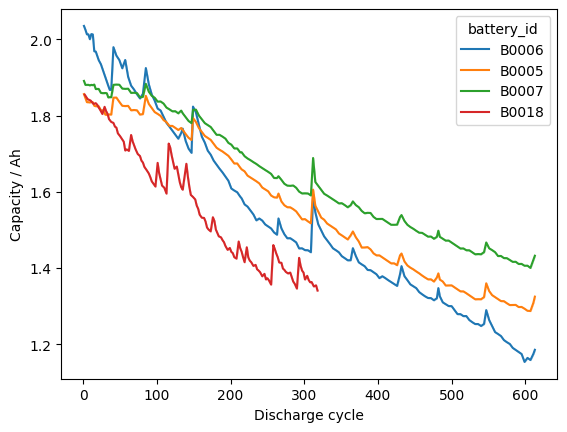

In [23]:
#Plotting the Change of capacity during cycles

sns.lineplot(B1_charge_discharge, x="test_id", y="Capacity", hue="battery_id")
plt.xlabel("Discharge cycle")
plt.ylabel("Capacity / Ah")
plt.show()


- Not all batteries start with a capacity at the nominal value of 2 Ah.
    - SOH remains with the same nominal capacity
    - SOC can vary based on the first capacity

In [24]:
#Remaining useful life is based on the discharge capacity. 
#Calculate the first value per battery
#locate min value of test_id (usually 0 or 1) by the index

iCap_idx = B1_charge_discharge.loc[B1_charge_discharge["type"]=="discharge"].groupby("battery_id")["test_id"].idxmin()
#Locate the capacity value at each index
iCap = (B1_charge_discharge.loc[iCap_idx, ["battery_id", "Capacity"]].set_index("battery_id")["Capacity"])
#SoH would be this value over 2 Ah

#Calculate the EoL capacity for each battery
Cap_70 = iCap*0.7
iCap
Cap_70 
#This is returning a series where the index is the battery id

for battery in iCap_idx.index: 
    EoL = Cap_70[battery]
    #Now, we need to find in which cycle the capacity reaches this value. 
    #Gather data per battery
    subdf = B1_charge_discharge.loc[(B1_charge_discharge["type"]=="discharge")&(B1_charge_discharge["battery_id"]==battery)]
    #Find where the capacity is below or at this value with a tolerance
    subdf_EoL = subdf.loc[subdf["Capacity"] < EoL]
    
    if not subdf_EoL.empty:
        RuL_cycle = subdf_EoL["test_id"].iloc[0]
    else: 
        RuL_cycle = None

    print(battery,RuL_cycle)



B0005 591
B0006 359
B0007 None
B0018 None


In [25]:
iCap_idx

battery_id
B0005     592247
B0006        789
B0007    1183705
B0018    1777190
Name: test_id, dtype: int64

In [26]:
SoH = B1_charge_discharge.loc[B1_charge_discharge["type"] == "discharge"].groupby(["battery_id", "test_id"], as_index=False).agg({"Capacity":"mean"})
SoH["SoH"] = SoH["Capacity"]/SoH["battery_id"].map(iCap)

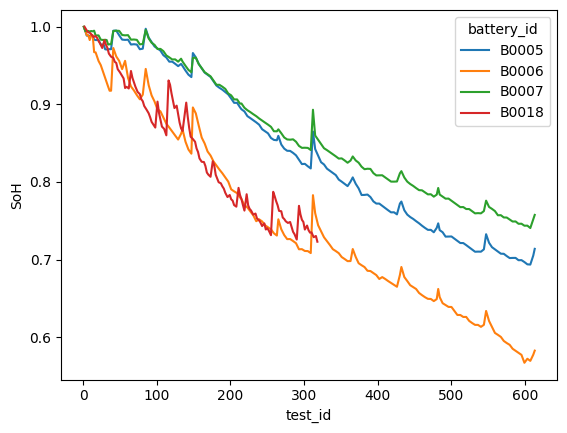

In [27]:
sns.lineplot(SoH, x="test_id", y="SoH", hue="battery_id")
plt.show()

In [29]:
from utils import current_capacity
B1_charge_discharge=current_capacity(B1_charge_discharge)


KeyboardInterrupt: 

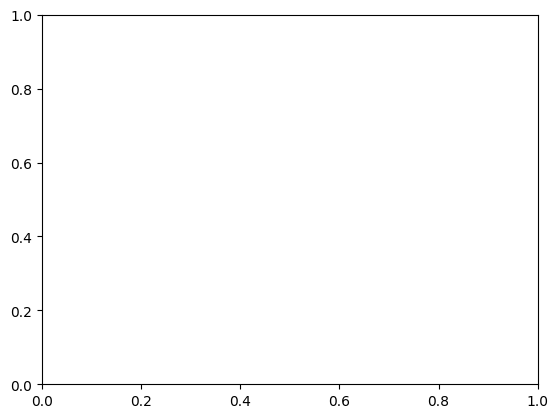

In [30]:
sns.lineplot(B1_charge_discharge, x="norm_time", y="capacity_Ah", hue="battery_id")
plt.xlim(-100,200000)
plt.show()

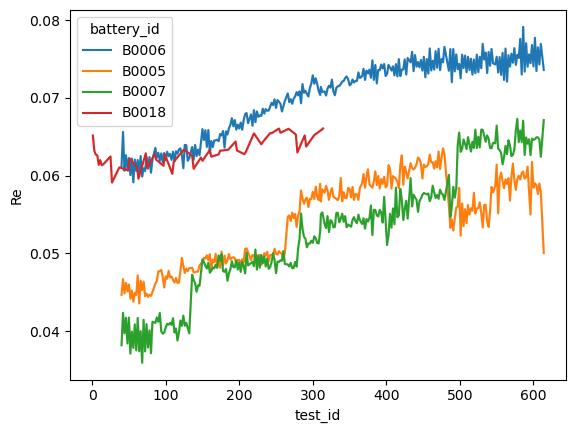

In [ ]:
sns.lineplot(B1_impedance, x="test_id", y="Re", hue="battery_id")
plt.show()

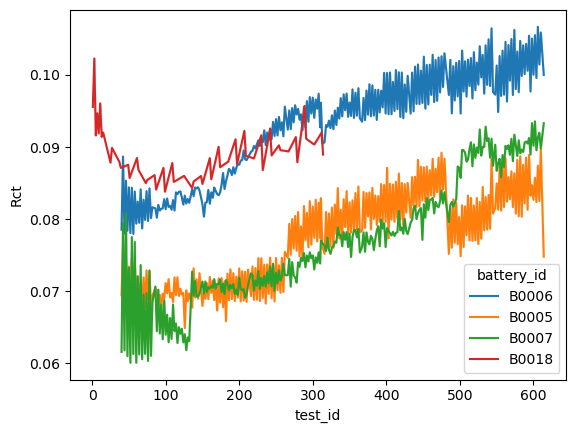

In [ ]:
sns.lineplot(B1_impedance, x="test_id", y="Rct", hue="battery_id")
plt.show()

# Data Visualization

## Charging

In [31]:
B1_charge = B1_charge_discharge.loc[B1_charge_discharge["type"]=="charge"]
B1_charge = B1_charge.sort_values(["battery_id", "test_id", "norm_time"]).reset_index(drop=True)


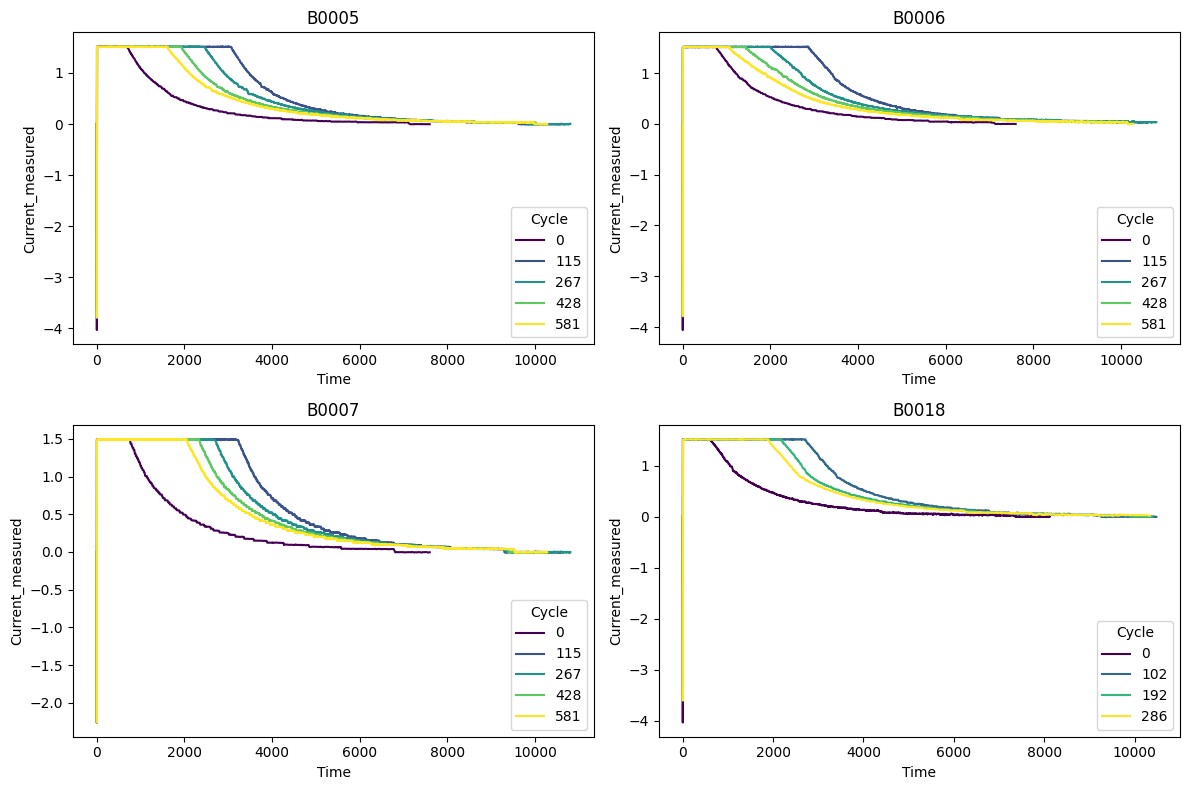

In [ ]:
importlib.reload(utils)
from utils import visualization_2by2
visualization_2by2(B1_charge, "Time", "Current_measured")
plt.tight_layout()
plt.show()

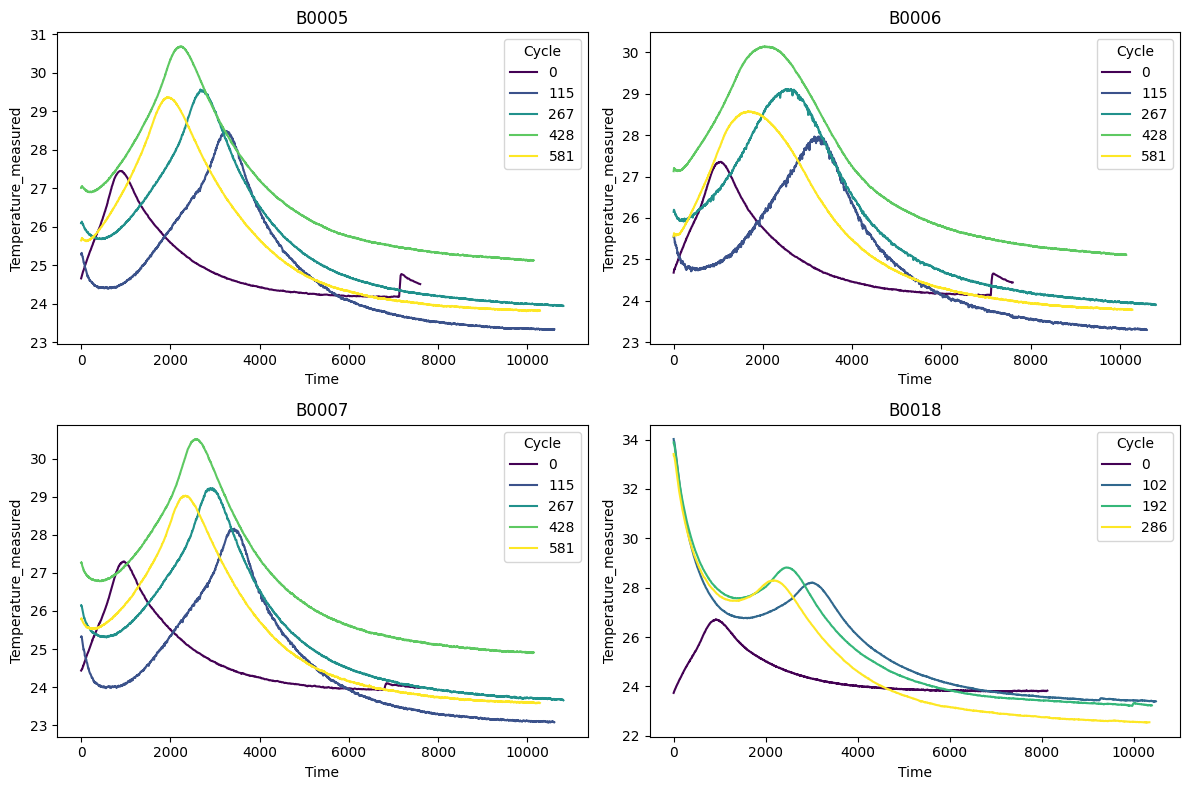

In [ ]:
visualization_2by2(B1_charge, "Time", "Temperature_measured")
plt.tight_layout()
plt.show()

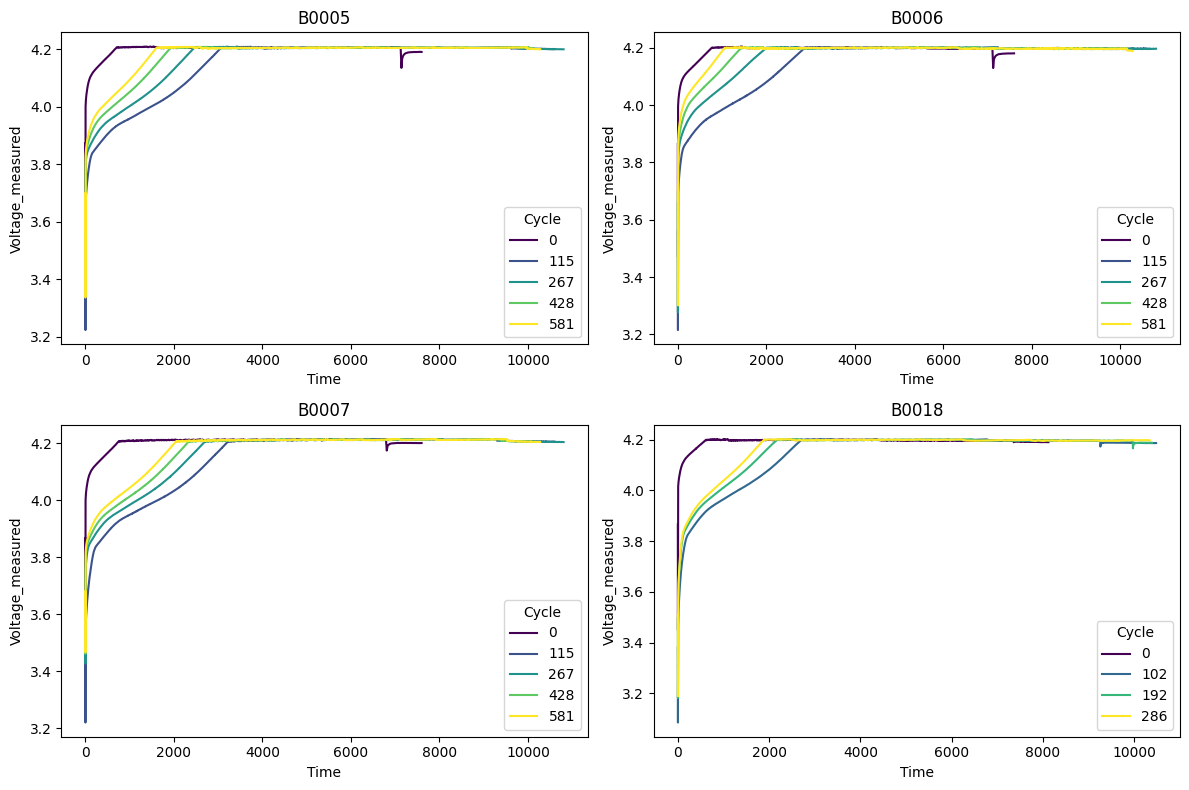

In [ ]:
visualization_2by2(B1_charge, "Time", "Voltage_measured")
plt.tight_layout()
plt.show()

<Axes: title={'center': 'B0018'}, xlabel='Time', ylabel='capacity_Ah'>

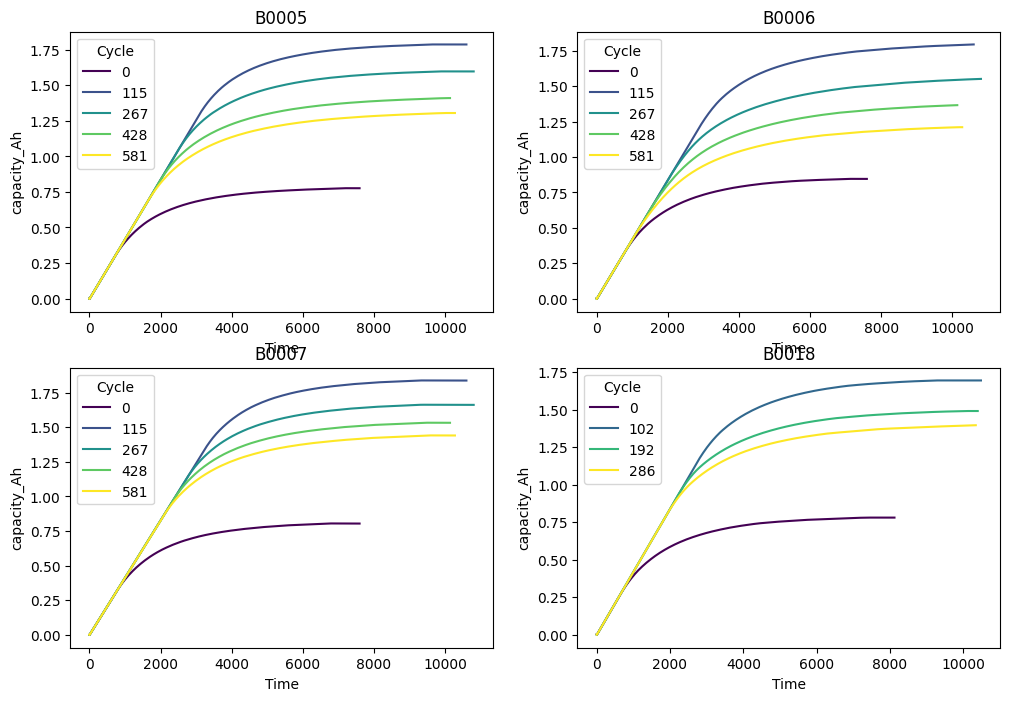

In [ ]:
importlib.reload(utils)
from utils import current_capacity
B1_charge_copy = current_capacity(B1_charge)
visualization_2by2(B1_charge_copy, "Time", "capacity_Ah")

In [ ]:
visualization_2by2(B1_charge_copy, "capacity_Ah","Voltage_measured")

## Main observations from B0005

1. Cycle 0 is not representative for the following behavior of the battery as it has not yet been stabilized. 
2. the increase of temperature during charging is associated to the time it takes to reach 4.2 V and finish the constant current phase. 
3. With increasing cycles, the battery behavior changes to what would be the opposite of aging, and might be due to reconfiguration of the anode and cathode structures after cycling. One may have to analyze the impedance spectra. 

## actions: 
1. Calculate the time it takes to get to 4.2 V for each cycle. 
2. Time of maximum temperature vs time of 4.2 V to charge. 
3. Fit exponentially the curve of discharge to compare evolution of charging efficiency. 

## Max Temperature

### Inflection point

In [44]:
B1_charge["dT/dt"] = B1_charge["Temperature_measured"].diff()/B1_charge["Time"].diff()


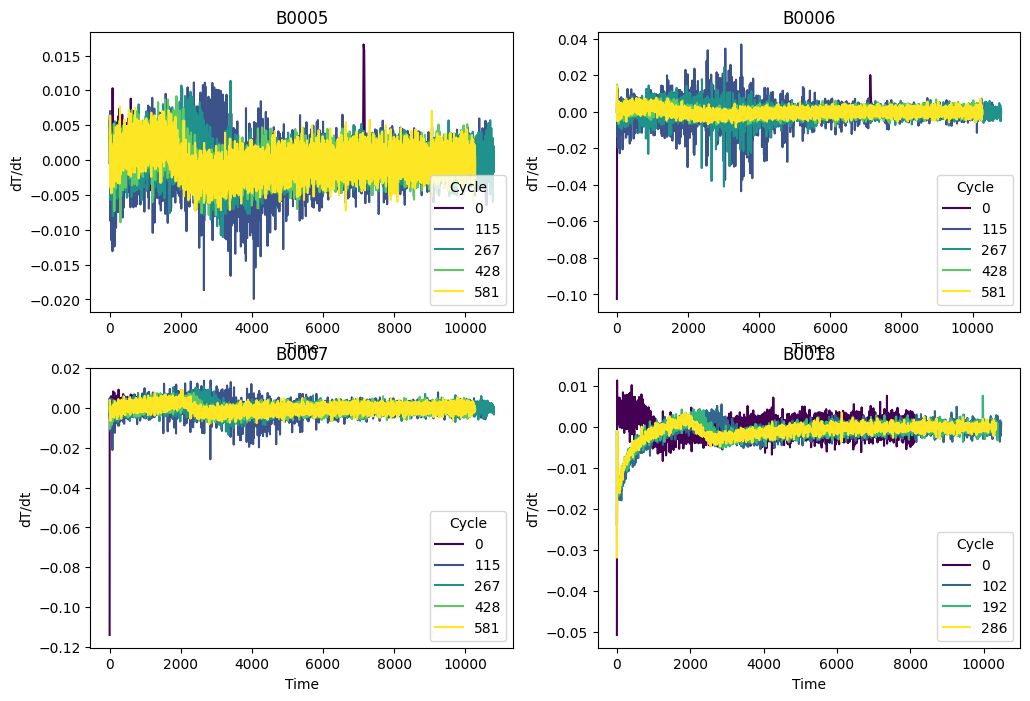

In [45]:
visualization_2by2(B1_charge,"Time","dT/dt")
plt.show()

Data is too noisy! 

### Peak detection

In [137]:
#Find a way to smooth the Temperature signal 
#B0006 sample 115
smooth_test = B1_charge[["Temperature_measured","Time"]].loc[((B1_charge["battery_id"]=="B0018")&(B1_charge["test_id"]==192))].reset_index(drop=True)

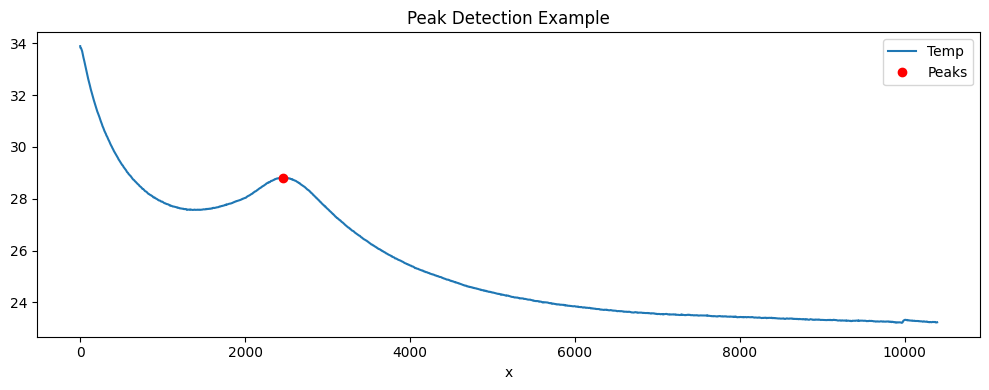

In [138]:
from scipy.signal import find_peaks
# Detect peaks
peaks, properties = find_peaks(smooth_test["Temperature_measured"],prominence=1, height = [5,35])
# Plot the results
plt.figure(figsize=(10,4))
plt.plot(smooth_test["Time"], smooth_test["Temperature_measured"], label='Temp')
plt.plot(smooth_test["Time"][peaks], smooth_test["Temperature_measured"][peaks], 'ro', label='Peaks')
plt.legend()
plt.xlabel('x')
plt.title('Peak Detection Example')
plt.tight_layout()
plt.show()

In [48]:
print(properties)

{'peak_heights': array([28.81932209]), 'prominences': array([1.25658875]), 'left_bases': array([256]), 'right_bases': array([1776])}


In [49]:
print(smooth_test["Time"][peaks])
print(smooth_test["Temperature_measured"][peaks])

460    2460.75
Name: Time, dtype: float64
460    28.819322
Name: Temperature_measured, dtype: float64


### Baseline with pybaseline

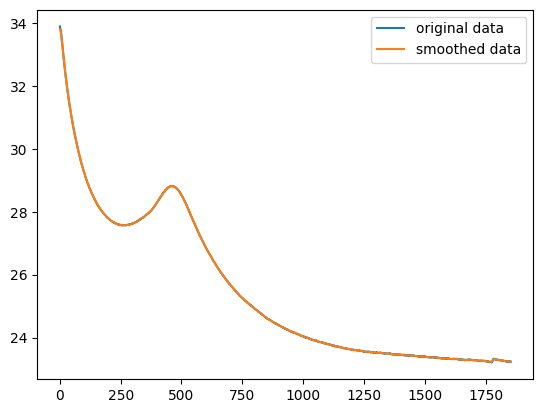

In [139]:
## We need to remove baseline, temperature in discharge can increase up to 40
from scipy.ndimage import uniform_filter1d
from pybaselines import Baseline
from pybaselines.utils import gaussian

smooth_y = uniform_filter1d(smooth_test["Temperature_measured"], 11)

plt.figure()
plt.plot(smooth_test["Temperature_measured"], label='original data')
plt.plot(smooth_y, label='smoothed data')
plt.legend()
        


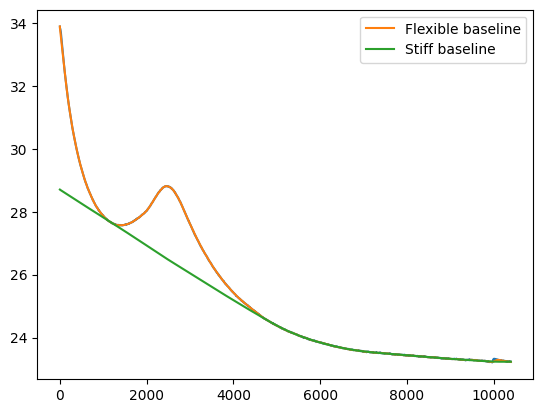

In [140]:
baseline_fitter = Baseline(x_data=smooth_test["Time"])
lam_flexible = 100
lam_stiff = 5e5
x=smooth_test["Time"]
flexible_baseline = baseline_fitter.arpls(smooth_test["Temperature_measured"], lam=lam_flexible)[0]
stiff_baseline = baseline_fitter.arpls(smooth_test["Temperature_measured"], lam=lam_stiff)[0]

plt.figure()
plt.plot(x, smooth_test["Temperature_measured"])
plt.plot(x, flexible_baseline, label='Flexible baseline')
plt.plot(x, stiff_baseline, label='Stiff baseline')
plt.legend()

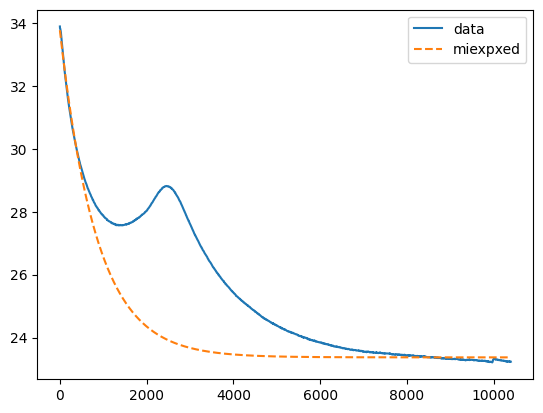

In [143]:

y = smooth_test["Temperature_measured"]
x=smooth_test["Time"]
baseline_fitter = Baseline(x_data=x)
flexible_baseline = baseline_fitter.arpls(y, lam=5e5)[0]
smoothed_imodpoly = baseline_fitter.imodpoly(y, poly_order=6, num_std=0.002)[0]
mixed = baseline_fitter.mixture_model(y, lam=1e3, p=0.5)[0]
isqr = baseline_fitter.irsqr(y, lam=5e5)[0]

crossover_index = np.argmin(abs(x -400))
lam_flexible = 1e2
fit_baseline, params = baseline_fitter.custom_bc(
    y, 'arpls',
    regions=([crossover_index, None],),
    sampling=15,
    method_kwargs={'lam': lam_flexible},
    lam=1e1
)

from scipy.optimize import curve_fit
import numpy as np
def exp_decay(x, A, k, c):

    return A * np.exp(-k * x) + c
mask = (
    (x < 500) |
    (x > 7000)
)
params, _ = curve_fit(
    exp_decay,
    x[mask],
    y[mask],
    p0=[10, 9e-2, 30]
)

baseline_exp = exp_decay(x, *params)

plt.figure()
plt.plot(x, y,label ='data')
#plt.plot(x, fit_baseline, label='Fit baseline')
#plt.plot(x,flexible_baseline, label='lam')
#plt.plot(x,smoothed_imodpoly, '--', label='smoothed modpoly')
#plt.plot(x,isqr, '--', label='isqr')
#plt.plot(x,mixed, '--', label='mixed')
plt.plot(x,baseline_exp, '--', label='miexpxed')
plt.legend()

In [148]:
from pybaselines import Baseline
from scipy.signal import find_peaks
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d

results_Tmax = []

grouped = B1_charge.groupby(["battery_id", "test_id"])

for (battery, cycle), cycle_df in grouped:

    cycle_df = cycle_df.sort_values("Time")
    cycle_df["Temp_smooth"] = gaussian_filter1d(cycle_df["Temperature_measured"],sigma=10)
    temp = cycle_df["Temp_smooth"].values

    time = cycle_df["Time"].values

    # Skip tiny cycles
    if len(time) < 20:
        continue

    def exp_decay(x, A, k, c):
        return A * np.exp(-k * x) + c
    
    c0= cycle_df["Temperature_measured"].iloc[-1]
    A0 = cycle_df["Temperature_measured"].iloc[0]-c0
    duration = cycle_df["Time"].max()
    k0 = 1/ duration

    p0 = (A0, k0, c0)

    mask = ((time < 500) | (time > 7000))
    params, _ = curve_fit(
        exp_decay,
        time[mask],
        temp[mask],
        p0=p0,
        maxfev=10000)

    baseline_exp = exp_decay(time, *params)

    y = temp - baseline_exp

    peaks, properties = find_peaks(y,prominence=1)

    if (len(peaks) == 0 or len(properties["prominences"]) == 0):

        print(f"No valid peak for "f"{battery}, cycle {cycle}")

        t_peak = np.nan
        T_peak = np.nan

    else:

        main_peak = peaks[np.argmax(properties["prominences"])]

        t_peak = time[main_peak]

        T_peak = y[main_peak]


        results_Tmax.append({
            "battery_id": battery,
            "test_id": cycle,
            "time_Tmax": t_peak,
            "T_peak": T_peak})



No valid peak for B0005, cycle 84
No valid peak for B0006, cycle 84
No valid peak for B0007, cycle 84
No valid peak for B0018, cycle 115
No valid peak for B0018, cycle 139


<Axes: xlabel='test_id', ylabel='time_Tmax'>

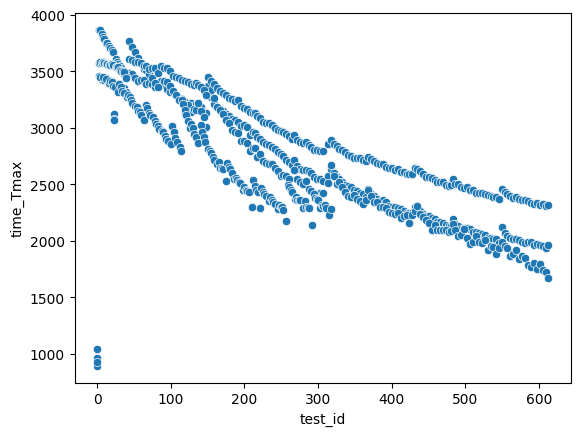

In [150]:
results_Tmax_df = pd.DataFrame(results_Tmax)
sns.scatterplot(data=results_Tmax_df, x="test_id", y="time_Tmax")

### Just by max value

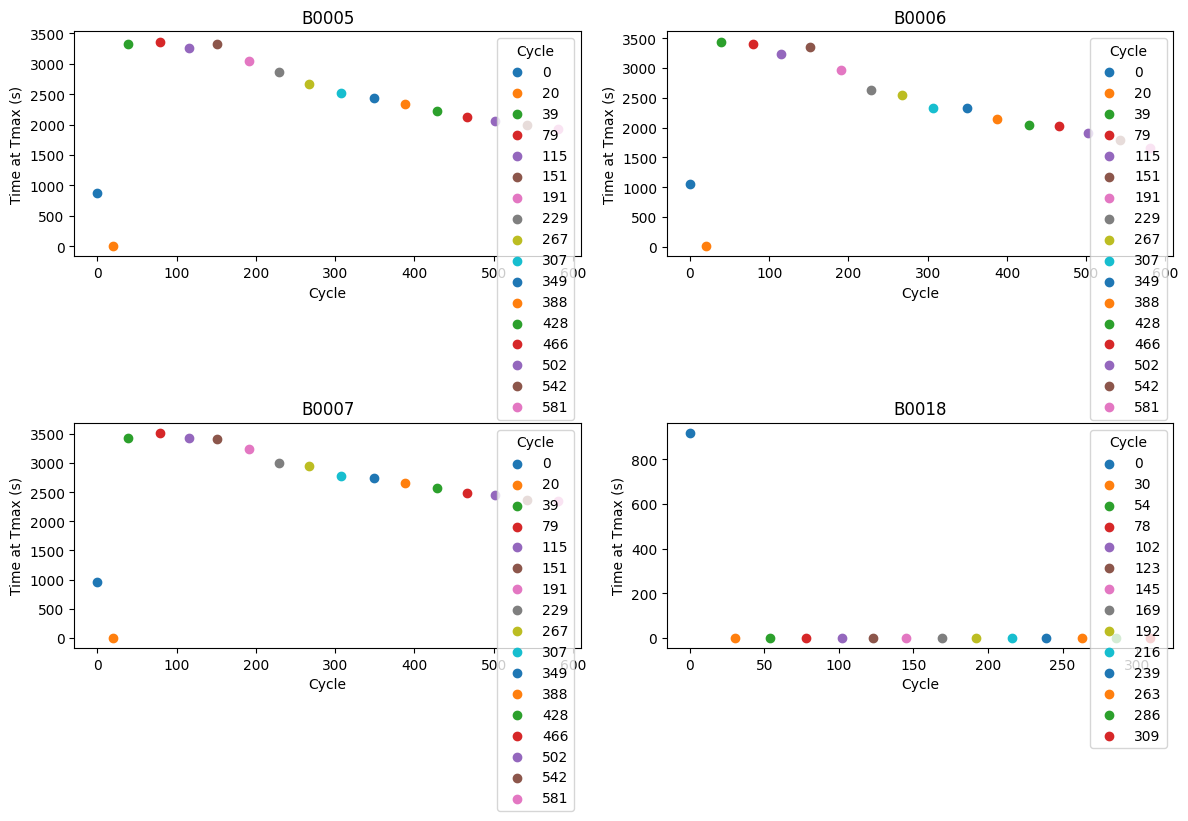

In [79]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

ax = ax.flatten()

batteries = B1_charge["battery_id"].unique()

for index, battery in enumerate(batteries):

    battery_df = B1_charge[B1_charge["battery_id"] == battery]

    cycles = battery_df["test_id"].unique()[::10]

    for cycle in cycles:

        cycle_df = battery_df[battery_df["test_id"] == cycle]

        # index label of Tmax
        idx_Tmax = cycle_df["Temperature_measured"].idxmax()

        # time where Tmax occurs
        time_Tmax = cycle_df.loc[idx_Tmax, "Time"]

        ax[index].scatter(cycle,time_Tmax,label=f"{cycle}")

    ax[index].set_title(battery)

    ax[index].set_xlabel("Cycle")
    ax[index].set_ylabel("Time at Tmax (s)")

    ax[index].legend(title="Cycle")


plt.tight_layout()
plt.show()

### Area under T curve

(200000.0, 300000.0)

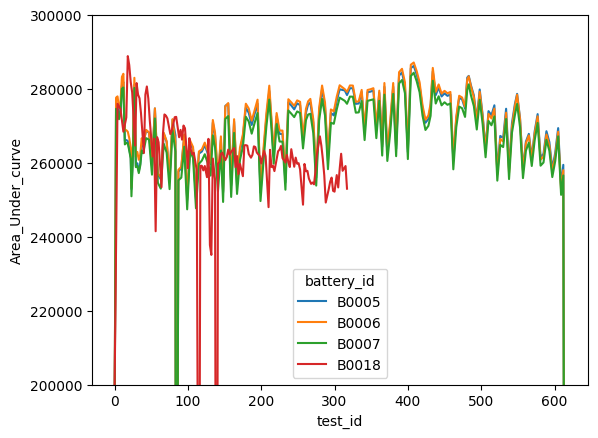

In [126]:
T_area = area_under_curve(df=B1_charge, x= "Time",y="Temperature_measured")
sns.lineplot(data=T_area, x=T_area["test_id"],y=T_area["Area_Under_curve"], hue="battery_id")
plt.ylim(200000,300000)

## Voltage

In [ ]:
#define a time to voltage
def time_to_voltage(df, voltage_target = 4.2, tolerance = 0.05):
    import pandas as pd
    results = []
    grouped = df.groupby(["battery_id", "test_id"])
    for (battery, cycle), cycle_df in grouped:

        cycle_df = cycle_df.sort_values("Time")
        voltage = cycle_df["Voltage_measured"]
        mask = (np.abs(voltage-voltage_target))<=tolerance

        #required to sustain the value
        window=3
        rolling_hits = (mask.rolling(window).sum())
        idx = rolling_hits[rolling_hits==window].index
        
        if len(idx) ==0:
            t_reach= np.nan
        else: 
            first_idx = idx[0]
            t_reach=cycle_df.loc[first_idx,"Time"]
        results.append({
            "battery_id": battery,
            "test_id": cycle,
            "time_to_4p2V": t_reach
        })
    return pd.DataFrame(results)



<Axes: xlabel='test_id', ylabel='time_to_4p2V'>

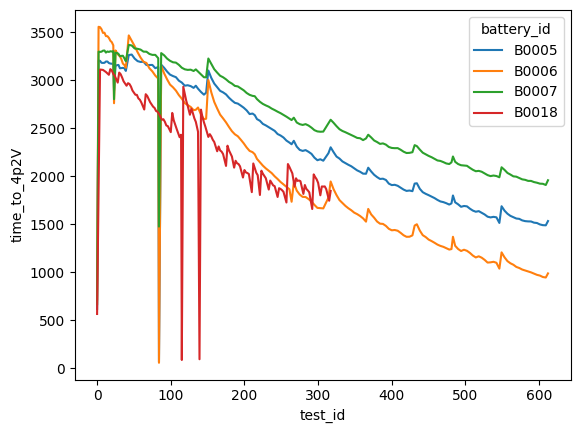

In [195]:
Time_to_42V = time_to_voltage(B1_charge, 4.2, 0.01)
sns.lineplot(data=Time_to_42V, x= Time_to_42V["test_id"], y=Time_to_42V["time_to_4p2V"], hue="battery_id")

<Axes: xlabel='test_id', ylabel='exp_coefficient'>

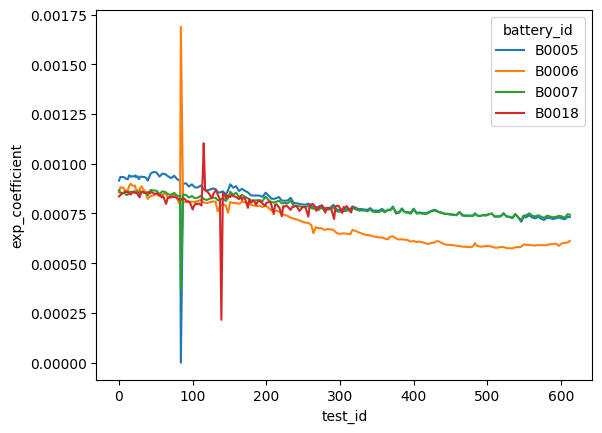

In [240]:
Charge_decay = charging_decay(B1_charge)
sns.lineplot(data=Charge_decay, x= Charge_decay["test_id"], y=Charge_decay["exp_coefficient"], hue="battery_id")

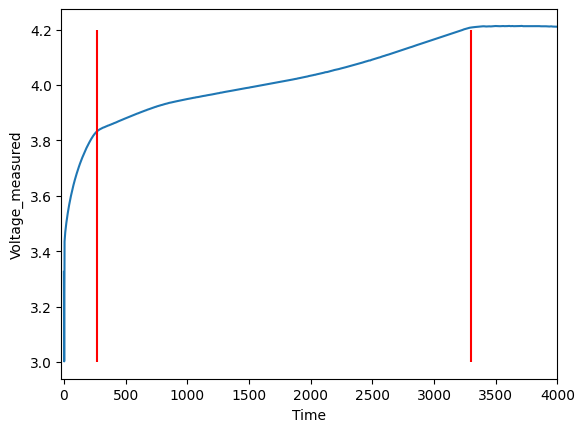

In [79]:
sns.lineplot(data=B1_charge.loc[((B1_charge["battery_id"]=="B0005")&(B1_charge["test_id"]==2))], x="Time", y="Voltage_measured")
plt.xlim(-20,4000)
plt.vlines(x=270, ymin=3, ymax=4.2, color="red")
plt.vlines(x=3300, ymin=3, ymax=4.2,color="red")

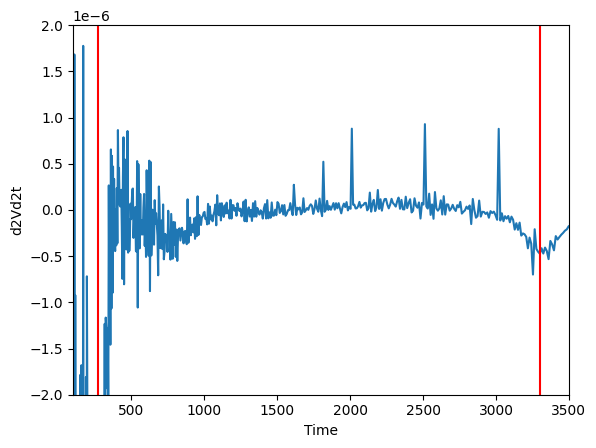

In [ ]:
## Select the dataframe with values that represent the slope 
#where the change od voltage ot capacity is positive 
from scipy.ndimage import gaussian_filter1d

B1_charge["V_smooth"] = gaussian_filter1d(B1_charge["Voltage_measured"],sigma=10)

B1_charge["dVdt"] = B1_charge["V_smooth"].diff()/B1_charge["Time"].diff()
B1_charge["d2Vd2t"] = B1_charge["dVdt"].diff()/B1_charge["Time"].diff()

sns.lineplot(data=B1_charge.loc[((B1_charge["battery_id"]=="B0005")&(B1_charge["test_id"]==2))], x="Time", y="d2Vd2t")
plt.xlim(100,3500)
plt.ylim(-2e-6,2e-6)
plt.vlines(x=270, ymin=-1e3, ymax=1e3, color="red")
plt.vlines(x=3300, ymin=-1e3, ymax=1e3,color="red")


In [ ]:
d2Vd2t_mask =  ((B1_charge["d2Vd2t"]>=-1e-6) & (B1_charge["d2Vd2t"]<= 2e-6))
V_mask = (d2Vd2t_mask & (B1_charge["Voltage_measured"]< 4.18))
V_mask2 = (V_mask & (B1_charge["Voltage_measured"]> 3.8))
V_mask3 = (V_mask2 & (B1_charge["Current_measured"]> 1))
slopeV = B1_charge[["battery_id","test_id","Voltage_measured","Time","Current_measured","capacity_Ah"]][V_mask3]


In [122]:
from scipy.stats import linregress
results_slopes = []

grouped = slopeV.groupby(["battery_id", "test_id"])

for (battery, cycle), cycle_df in grouped:
    cycle_df = cycle_df.sort_values("Time")
        
    x = cycle_df["capacity_Ah"]

    y = cycle_df["Voltage_measured"]

    res = linregress(x, y)
    

      
    results_slopes.append({
        "battery_id": battery,
        "test_id": cycle,
        "slope": res.slope,
        "intercept": res.intercept
        })


<Axes: xlabel='test_id', ylabel='slope'>

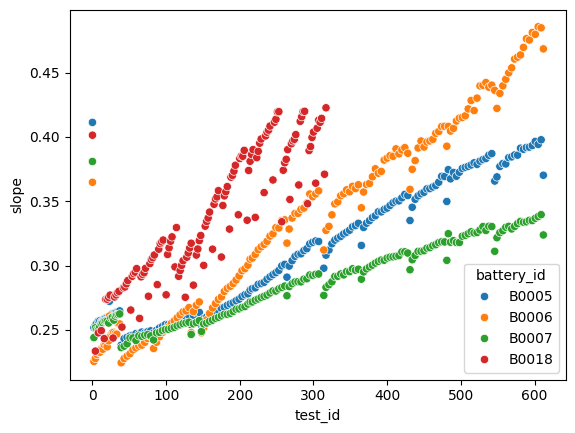

In [127]:
result_slopes_df = pd.DataFrame(results_slopes)
sns.scatterplot(data=result_slopes_df, x="test_id", y="slope", hue="battery_id")

<Axes: title={'center': 'B0018'}, xlabel='capacity_Ah', ylabel='Voltage_measured'>

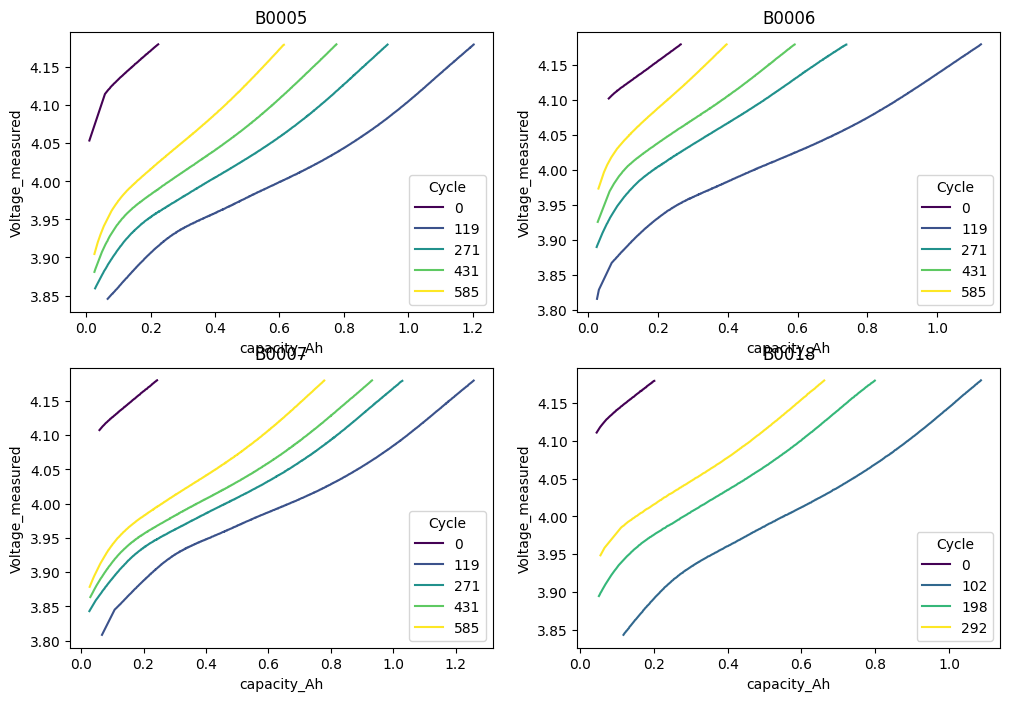

In [117]:
visualization_2by2(slopeV, x="capacity_Ah", y="Voltage_measured")

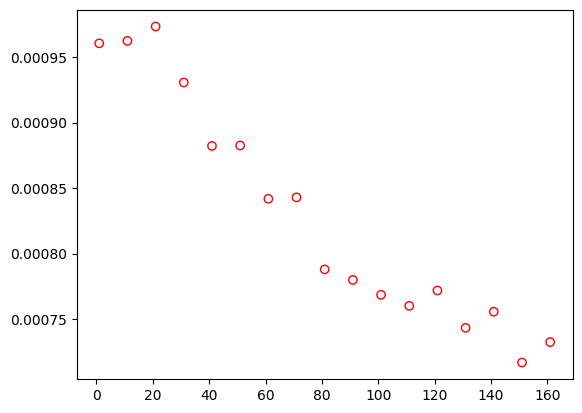

In [ ]:
from scipy.optimize import curve_fit

def func(x, a, c, d):
    return a*np.exp(-c*x)+d

cycles = range(1,170,10)

for idx,i in enumerate(cycles):
    cycle = charge_dict["B0005"][i]
    filepath = cycle["filepath"]
    data = pd.read_csv(filepath)
    data["Time"] = data["Time"]-data["Time"].iloc[0]
    idx_42V = data.loc[data["Voltage_measured"]>=4.2].first_valid_index()
    CV_phase = data.iloc[idx_42V:]
    popt, pcov = curve_fit(func, CV_phase["Time"], CV_phase["Current_measured"], p0=(1, 1e-6, 1))
    #y = func(CV_phase["Time"],popt[0],popt[1],popt[2])
    plt.scatter(i,popt[1],facecolors='none', edgecolors='r')

## Features extracted from charging: 
1. Time it takes to reach 4.2 V
2. Time of max temperature
3. Exponential coefficient of the CV phase.

# Discharge

In [152]:
B1_discharge = B1_charge_discharge.loc[B1_charge_discharge["type"]=="discharge"]
B1_discharge.reset_index(drop=True)


,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time,type,test_id,battery_id,start_time,Capacity,Current_load,Voltage_load,real_time,norm_time,capacity_Ah
0,4.191492,-0.004902,24.330034,NaN,NaN,0.000,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-0.0006,0.000,1.207150e+06,8.243672,0.000000
1,4.190749,-0.001478,24.325993,NaN,NaN,16.781,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-0.0006,4.206,1.207167e+06,25.024672,-0.000007
2,3.974871,-2.012528,24.389085,NaN,NaN,35.703,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-1.9982,3.062,1.207186e+06,43.946672,-0.010585
3,3.951717,-2.013979,24.544752,NaN,NaN,53.781,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-1.9982,3.030,1.207204e+06,62.024672,-0.020698
4,3.934352,-2.011144,24.731385,NaN,NaN,71.922,discharge,1,B0005,2008-04-02 15:25:41.593,1.856487,-1.9982,3.011,1.207222e+06,80.165672,-0.030833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185716,3.443760,-0.002426,35.383979,NaN,NaN,2686.359,discharge,318,B0018,2008-08-20 08:37:19.515,1.341051,0.0006,0.000,1.221908e+06,6474.192765,-1.360587
185717,3.453271,-0.000981,35.179732,NaN,NaN,2700.546,discharge,318,B0018,2008-08-20 08:37:19.515,1.341051,0.0006,0.000,1.221922e+06,6488.379765,-1.360591
185718,3.461963,0.000209,34.977000,NaN,NaN,2714.640,discharge,318,B0018,2008-08-20 08:37:19.515,1.341051,0.0006,0.000,1.221936e+06,6502.473765,-1.360590
185719,3.469907,0.001516,34.785943,NaN,NaN,2728.750,discharge,318,B0018,2008-08-20 08:37:19.515,1.341051,0.0006,0.000,1.221950e+06,6516.583765,-1.360584


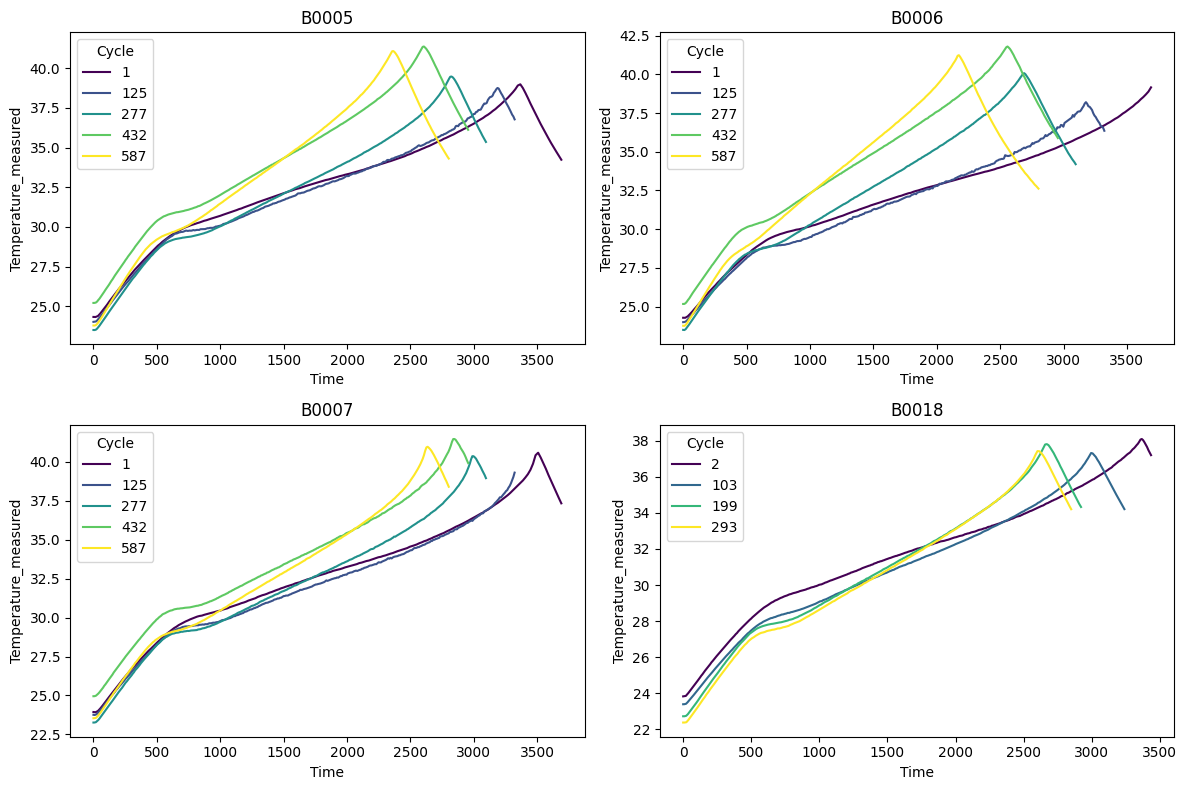

In [154]:
from utils import visualization_2by2
visualization_2by2(B1_discharge, "Time", "Temperature_measured")
plt.tight_layout()
plt.show()

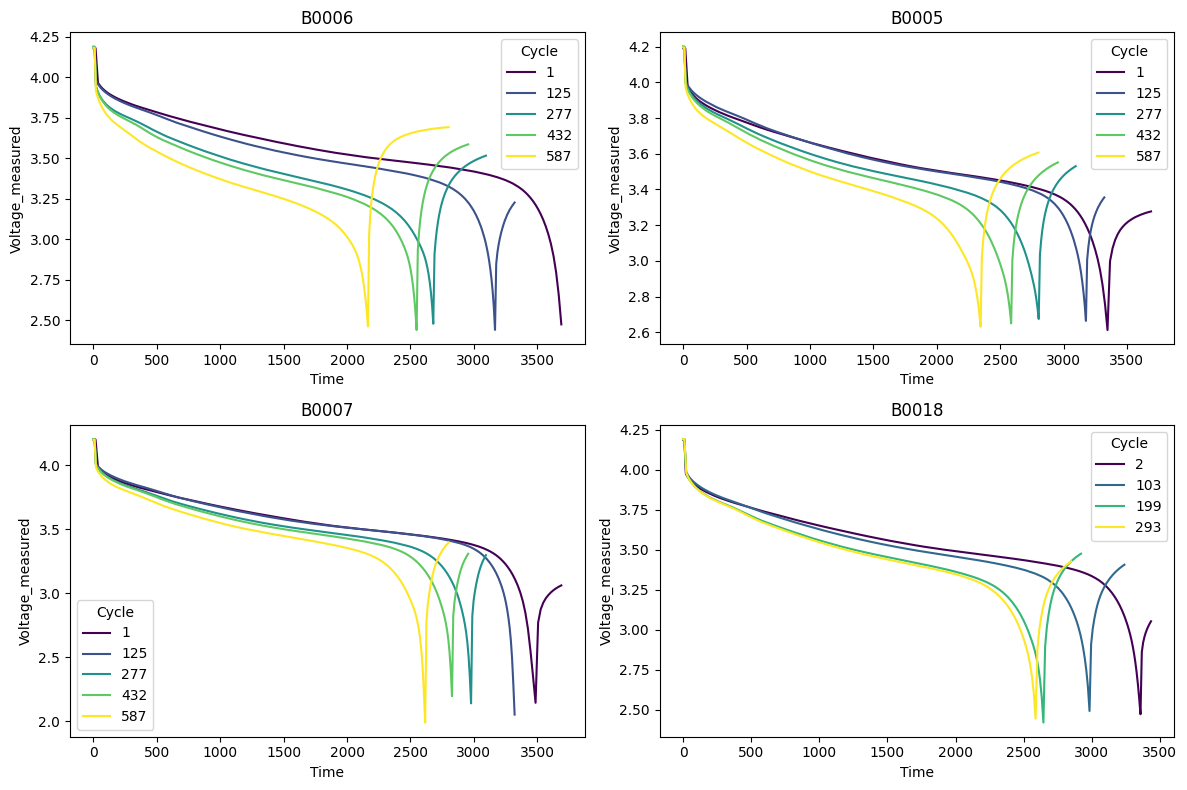

In [ ]:
visualization_2by2(B1_discharge, "Time", "Voltage_measured")
plt.tight_layout()
plt.show()

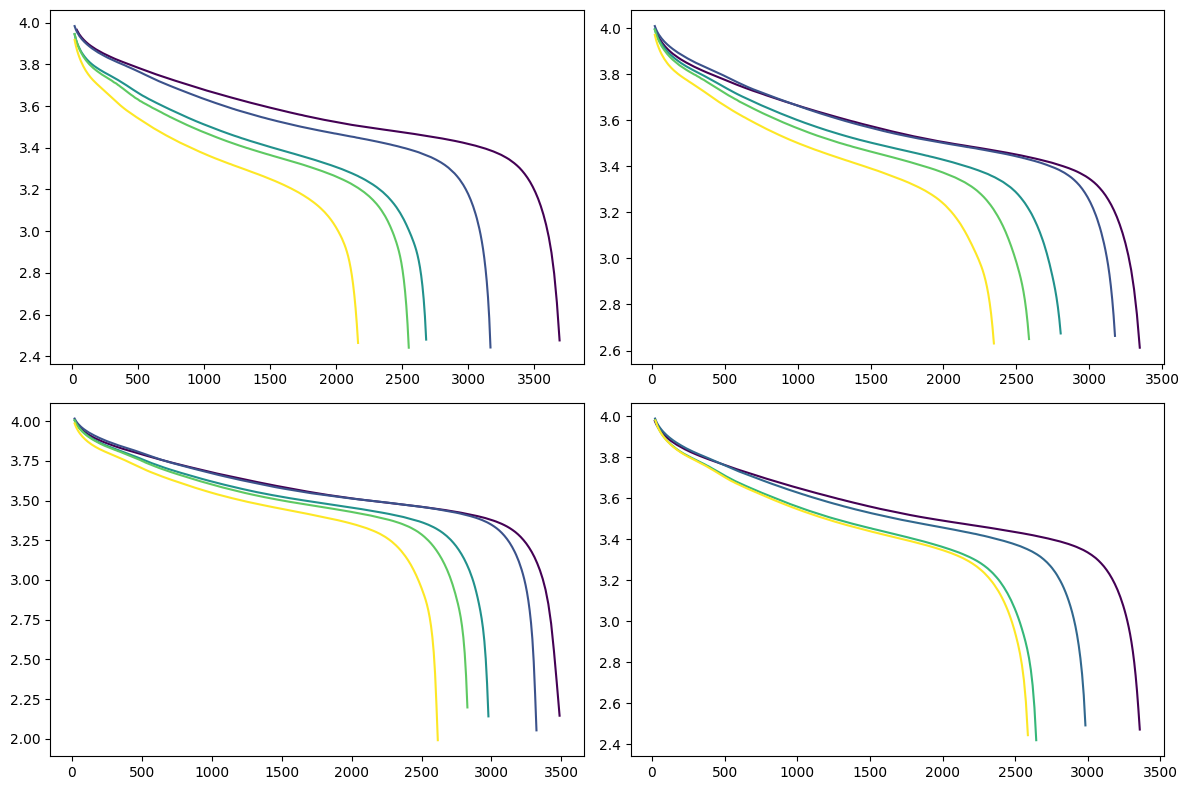

In [ ]:
# Ploting every 15th cycles from batteries B0005
import matplotlib as mpl
fig,ax = plt.subplots(2,2,figsize=(12,8))

ax = ax.flatten()

batteries = B1_discharge["battery_id"].unique()

cmap = plt.cm.viridis

for index,battery in enumerate(batteries):
    
    battery_df = B1_discharge[B1_discharge["battery_id"]==battery]
    
    cycles = battery_df["test_id"].unique()[::40]

    for j, cycle in enumerate(cycles):

        color = cmap(j / (len(cycles)-1))

        cycle_df = battery_df[battery_df["test_id"] == cycle].copy()

        # remove first transient points
        cycle_df = cycle_df.iloc[2:]
        threshold = -1.7
        mask = cycle_df.loc[cycle_df["Current_measured"]<threshold]

       
        ax[index].plot(
            mask["Time"],
            mask["Voltage_measured"],
            label=f"{cycle}",
            color=color)
plt.tight_layout()
plt.show()
    